# Notebook 03 — Probabilistic Forecasting

## What this notebook does

All models in Notebook 01 produce **point predictions** — one number per week.
This notebook converts every model into a **probabilistic forecast** — a full prediction
interval (a range with a stated confidence level).

### Method: Split Conformal Prediction
For each walk-forward step, the last 26 weeks of the training window are used as a
**calibration set**. The calibration residuals define how uncertain the model is.
At test time, the prediction interval is:
$$\hat{y} \pm \hat{q}_{1-\alpha}(\text{calibration residuals})$$
This provides a **coverage guarantee**: 90% of true values fall inside the 90% interval.

### Additional model: Quantile GBM
A native probabilistic model trained directly to predict the 5th, 50th, and 95th percentiles
using `HistGradientBoostingRegressor(loss='quantile')`.

### Metrics
| Metric | What it measures |
|---|---|
| **CRPS** | Overall quality of the full predicted distribution (lower = better) |
| **Coverage (90%)** | % of actual values inside the 90% prediction interval (target ≈ 0.90) |
| **Interval Width** | Average width of the 90% interval (narrower = better, given coverage is met) |
| **Pinball loss** | Error at specific quantiles (10th, 50th, 90th) |

Models included: Random Walk, AR(1), Rolling Avg (4/8/12), GBM (lags=5),
Quantile GBM, LSTM (seq=5), Hurdle (lags=5).
*(Long Run Mean and Long Run Median excluded — dominated by all other models.)*

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
from scipy import stats as sp_stats
from scipy.special import ndtr   # fast normal CDF
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
ROOT = Path('..')

from src.walkforward import rolling_week_splits
from src.features import FEATURE_COLS, build_tabular

# Colour palette (consistent with Notebook 01)
MODEL_COLORS = {
    'Random Walk'    : '#888888',
    'AR(1)'          : '#4e79a7',
    'Rolling Avg (4)': '#76b7b2',
    'Rolling Avg (8)': '#59a14f',
    'Rolling Avg(12)': '#b07aa1',
    'GBM (lags=5)'   : '#e05c1a',
    'Quantile GBM'   : '#c0392b',
    'LSTM (seq=5)'   : '#7d3c98',
    'Hurdle (lags=5)': '#17a589',
}

print('Setup complete.')

Setup complete.


---
## Section 1 — Load Data and Splits

In [2]:
panel   = pd.read_parquet(ROOT / 'data' / 'processed' / 'panel.parquet')
tabular = build_tabular(panel)
splits  = rolling_week_splits()

print(f'Panel   : {panel.shape}')
print(f'Tabular : {tabular.shape}')
print(f'Splits  : {len(splits)} walk-forward steps')

Panel   : (25382, 9)
Tabular : (24790, 51)
Splits  : 52 walk-forward steps


---
## Section 2 — Probabilistic Evaluation Metrics

These functions take a predictions DataFrame that includes not just `y_pred` (the point prediction)
but also `q05`, `q50`, `q95` (the 5th, 50th, 95th percentile predictions).

In [ ]:
# ── Metric functions ──────────────────────────────────────────────────────────

def gaussian_crps(mu: np.ndarray, sigma: np.ndarray, y: np.ndarray) -> np.ndarray:
    """
    Closed-form CRPS for a Gaussian predictive distribution N(mu, sigma^2).
    Used for conformal models, where the predictive distribution is Gaussian
    by construction (sigma = std of calibration residuals).
    Formula: sigma * [z(2*Phi(z) - 1) + 2*phi(z) - 1/sqrt(pi)]
    """
    sigma = np.maximum(sigma, 1e-8)
    z     = (y - mu) / sigma
    crps  = sigma * (z * (2 * sp_stats.norm.cdf(z) - 1)
                     + 2 * sp_stats.norm.pdf(z)
                     - 1 / np.sqrt(np.pi))
    return crps


# ── Empirical CRPS for Quantile GBM (pinball decomposition) ───────────────────
# Nine equidistant quantile levels (deciles) — Makridakis et al. (2022) convention;
# approximation converges to true CRPS as grid spacing → 0 (Gneiting & Raftery, 2007).
CRPS_TAUS = [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

def empirical_crps(preds_df: pd.DataFrame) -> np.ndarray:
    """
    CRPS ≈ (2/K) * Σ_k ρ_{τ_k}(y, q̂_{τ_k})  over K=9 decile quantiles.
    Requires columns q10, q20, ..., q90 in preds_df.
    No parametric assumption — valid for any predictive distribution.
    """
    y = preds_df['y_true'].values
    scores = np.zeros(len(y))
    for tau in CRPS_TAUS:
        col   = f'q{int(round(tau * 100)):02d}'
        q_hat = preds_df[col].values
        e     = y - q_hat
        scores += np.maximum(tau * e, (tau - 1) * e)
    return (2 / len(CRPS_TAUS)) * scores


def pinball_loss(y_true: np.ndarray, y_pred_q: np.ndarray, q: float) -> float:
    """Pinball (quantile) loss at quantile q."""
    e = y_true - y_pred_q
    return float(np.mean(np.maximum(q * e, (q - 1) * e)))


def coverage(y_true: np.ndarray, lower: np.ndarray, upper: np.ndarray) -> float:
    """Proportion of true values inside the prediction interval."""
    return float(np.mean((y_true >= lower) & (y_true <= upper)))


def evaluate_probabilistic(preds_df: pd.DataFrame, sigma_col: str = 'sigma') -> dict:
    """
    Gaussian CRPS evaluation for conformal models.
    Predictive distribution is N(mu, sigma^2) by construction.
    Required columns: y_true, y_pred, q05, q95, sigma.
    """
    yt  = preds_df['y_true'].values
    mu  = preds_df['y_pred'].values
    sg  = preds_df[sigma_col].values
    q05 = preds_df['q05'].values
    q95 = preds_df['q95'].values

    crps_vals = gaussian_crps(mu, sg, yt)

    return {
        'CRPS (mean)'     : round(float(crps_vals.mean()), 4),
        'Coverage 90%'    : round(coverage(yt, q05, q95), 3),
        'Interval Width'  : round(float((q95 - q05).mean()), 4),
        'Pinball (q=0.10)': round(pinball_loss(yt, q05, 0.10), 4),
        'Pinball (q=0.50)': round(pinball_loss(yt, mu,  0.50), 4),
        'Pinball (q=0.90)': round(pinball_loss(yt, q95, 0.90), 4),
        'RMSE (point)'    : round(float(np.sqrt(np.mean((yt - mu)**2))), 4),
    }


def evaluate_quantile_gbm(preds_df: pd.DataFrame) -> dict:
    """
    Empirical CRPS evaluation for Quantile GBM — no parametric assumption.
    CRPS from 9 decile quantiles via pinball decomposition.
    Coverage and width from q05/q95 (the 90% prediction interval).
    """
    yt  = preds_df['y_true'].values
    q50 = preds_df['q50'].values
    q05 = preds_df['q05'].values
    q95 = preds_df['q95'].values

    crps_vals = empirical_crps(preds_df)

    return {
        'CRPS (mean)'     : round(float(crps_vals.mean()), 4),
        'Coverage 90%'    : round(coverage(yt, q05, q95), 3),
        'Interval Width'  : round(float((q95 - q05).mean()), 4),
        'Pinball (q=0.10)': round(pinball_loss(yt, preds_df['q10'].values, 0.10), 4),
        'Pinball (q=0.50)': round(pinball_loss(yt, q50, 0.50), 4),
        'Pinball (q=0.90)': round(pinball_loss(yt, preds_df['q90'].values, 0.90), 4),
        'RMSE (point)'    : round(float(np.sqrt(np.mean((yt - q50)**2))), 4),
    }


print('Metric functions defined.')
print('  gaussian_crps        — closed-form CRPS for N(mu, sigma^2)  [conformal models]')
print('  empirical_crps       — pinball decomposition over 9 deciles  [Quantile GBM]')
print('  evaluate_probabilistic   — Gaussian CRPS evaluator')
print('  evaluate_quantile_gbm    — empirical CRPS evaluator')

---
## Section 3 — Conformal Prediction Wrapper

**How it works:**
1. For each walk-forward step, the last 26 training weeks are the *calibration set*
2. Run the point model on calibration → compute residuals |y_cal - ŷ_cal|
3. σ = std(calibration residuals) — the model's local uncertainty
4. 90% prediction interval = [ŷ − 1.645σ, ŷ + 1.645σ] (Gaussian approximation)
5. Conformal adjustment: replace 1.645 with the (1−α)(1+1/n) quantile of residuals

In [4]:
# ── Conformal wrapper ─────────────────────────────────────────────────────────

def conformal_intervals(cal_residuals: np.ndarray, point_pred: float,
                        alpha: float = 0.10):
    """
    Split conformal prediction interval at level (1-alpha).
    Returns: (q05, q95, sigma)
      q05, q95  — lower and upper bounds of the (1-alpha) interval
      sigma     — calibration std (used for Gaussian CRPS)
    """
    n     = len(cal_residuals)
    # Conformal quantile: (1-alpha)(1+1/n) to ensure finite-sample coverage
    level = min((1 - alpha) * (1 + 1 / n), 1.0)
    q_hat = float(np.quantile(cal_residuals, level))
    sigma = float(cal_residuals.std()) + 1e-8
    return (max(0.0, point_pred - q_hat),
            point_pred + q_hat,
            sigma)


print('conformal_intervals() defined.')
print('  alpha=0.10 → 90% prediction intervals')

conformal_intervals() defined.
  alpha=0.10 → 90% prediction intervals


---
## Section 4 — Probabilistic Baselines

In [5]:
# ── Probabilistic Random Walk ─────────────────────────────────────────────────

def run_rw_probabilistic(panel, splits, alpha=0.10):
    """Random Walk with conformal prediction intervals."""
    records = []
    for train_weeks, test_week in splits:
        cal_weeks = sorted(train_weeks)[-26:]          # last 26 weeks = calibration
        cal_data  = panel[panel['week_num'].isin(cal_weeks)].copy()

        # Point prediction on calibration: y_hat = y_lag1
        cal_resid = np.abs(cal_data['y'].values - cal_data['y_lag1'].fillna(0).values)

        test = panel[panel['week_num'] == test_week]
        for _, row in test.iterrows():
            pt = max(0.0, float(row['y_lag1']))
            q05, q95, sig = conformal_intervals(cal_resid, pt, alpha)
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'], 'y_pred': pt,
                            'q05': q05, 'q95': q95, 'sigma': sig})
    return pd.DataFrame(records)


# ── Probabilistic AR(1) ───────────────────────────────────────────────────────

def run_ar1_probabilistic(panel, splits, alpha=0.10):
    """AR(1) with conformal prediction intervals."""
    districts = sorted(panel['district'].unique())
    records   = []
    for train_weeks, test_week in splits:
        train     = panel[panel['week_num'].isin(train_weeks)]
        cal_weeks = sorted(train_weeks)[-26:]

        # Fit AR(1) coefficients on full training window
        coefs = {}
        for d in districts:
            sub = train[train['district'] == d][['y_lag1','y']].dropna()
            if len(sub) < 3:
                coefs[d] = (0.0, 1.0); continue
            A = np.column_stack([np.ones(len(sub)), sub['y_lag1'].values])
            c, *_ = np.linalg.lstsq(A, sub['y'].values, rcond=None)
            coefs[d] = (float(c[0]), float(c[1]))

        # Calibration residuals
        cal_data = panel[panel['week_num'].isin(cal_weeks)]
        cal_resid = []
        for _, row in cal_data.iterrows():
            a, b = coefs.get(row['district'], (0.0, 1.0))
            pt = max(0.0, a + b * float(row['y_lag1']))
            cal_resid.append(abs(row['y'] - pt))
        cal_resid = np.array(cal_resid)

        test = panel[panel['week_num'] == test_week]
        for _, row in test.iterrows():
            a, b = coefs.get(row['district'], (0.0, 1.0))
            pt   = max(0.0, a + b * float(row['y_lag1']))
            q05, q95, sig = conformal_intervals(cal_resid, pt, alpha)
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'], 'y_pred': pt,
                            'q05': q05, 'q95': q95, 'sigma': sig})
    return pd.DataFrame(records)


# ── Probabilistic Rolling Average ─────────────────────────────────────────────

def run_rolling_avg_probabilistic(panel, splits, window=4, alpha=0.10):
    """Rolling average with conformal prediction intervals."""
    records = []
    for train_weeks, test_week in splits:
        cal_weeks    = sorted(train_weeks)[-26:]
        recent_weeks = sorted(train_weeks)[-window:]

        means    = panel[panel['week_num'].isin(recent_weeks)].groupby('district')['y'].mean()
        cal_data = panel[panel['week_num'].isin(cal_weeks)]

        # Calibration residuals: rolling average prediction vs actual
        cal_resid = []
        for _, row in cal_data.iterrows():
            pt = float(means.get(row['district'], 0.0))
            cal_resid.append(abs(row['y'] - pt))
        cal_resid = np.array(cal_resid)

        test = panel[panel['week_num'] == test_week]
        for _, row in test.iterrows():
            pt = float(means.get(row['district'], 0.0))
            q05, q95, sig = conformal_intervals(cal_resid, pt, alpha)
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'], 'y_pred': pt,
                            'q05': q05, 'q95': q95, 'sigma': sig})
    return pd.DataFrame(records)


print('Probabilistic baseline functions defined.')

Probabilistic baseline functions defined.


In [6]:
print('Running probabilistic baselines ...')
print('  Random Walk ...')
rw_prob  = run_rw_probabilistic(tabular, splits)

print('  AR(1) ...')
ar1_prob = run_ar1_probabilistic(tabular, splits)

print('  Rolling Avg (4 weeks) ...')
ra4_prob = run_rolling_avg_probabilistic(tabular, splits, window=4)

print('  Rolling Avg (8 weeks) ...')
ra8_prob = run_rolling_avg_probabilistic(tabular, splits, window=8)

print('  Rolling Avg (12 weeks) ...')
ra12_prob = run_rolling_avg_probabilistic(tabular, splits, window=12)

print('Done.')

Running probabilistic baselines ...
  Random Walk ...
  AR(1) ...
  Rolling Avg (4 weeks) ...
  Rolling Avg (8 weeks) ...
  Rolling Avg (12 weeks) ...
Done.


---
## Section 5 — Probabilistic GBM (Conformal)

In [7]:
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.preprocessing import OrdinalEncoder


def _feat_cols(n_lags):
    return [f'{c}_lag{k}' for c in FEATURE_COLS for k in range(1, n_lags+1)] \
         + ['week_of_year', 'year']


def run_gbm_probabilistic(panel, splits, n_lags=5, alpha=0.10):
    """
    GBM point model + conformal prediction intervals.
    Calibration set: last 26 training weeks.
    """
    feat_cols = _feat_cols(n_lags)
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    enc.fit(panel[['district']])

    records = []
    for step_idx, (train_weeks, test_week) in enumerate(splits):
        if (step_idx + 1) % 10 == 0:
            print(f'    step {step_idx+1}/52 ...')

        cal_weeks  = sorted(train_weeks)[-26:]
        ptr_weeks  = sorted(train_weeks)[:-26]    # pure training

        ptr  = panel[panel['week_num'].isin(ptr_weeks)].dropna(subset=feat_cols)
        cal  = panel[panel['week_num'].isin(cal_weeks)].dropna(subset=feat_cols)
        test = panel[panel['week_num'] == test_week].dropna(subset=feat_cols)
        if len(ptr) == 0 or len(test) == 0:
            continue

        X_ptr  = np.hstack([enc.transform(ptr[['district']]),  ptr[feat_cols].values])
        X_cal  = np.hstack([enc.transform(cal[['district']]),  cal[feat_cols].values])
        X_test = np.hstack([enc.transform(test[['district']]), test[feat_cols].values])

        # Train point model on pure training
        model = HistGradientBoostingRegressor(
            loss='squared_error', max_iter=500, learning_rate=0.05,
            max_leaf_nodes=31, min_samples_leaf=20, random_state=42)
        model.fit(X_ptr, ptr['y'].values)

        # Calibration residuals
        cal_preds  = np.clip(model.predict(X_cal), 0, None)
        cal_resid  = np.abs(cal['y'].values - cal_preds)

        # Test predictions
        test_preds = np.clip(model.predict(X_test), 0, None)

        for (_, row), pt in zip(test.iterrows(), test_preds):
            q05, q95, sig = conformal_intervals(cal_resid, float(pt), alpha)
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'], 'y_pred': float(pt),
                            'q05': q05, 'q95': q95, 'sigma': sig})
    return pd.DataFrame(records)


print('Running GBM (conformal) lags=5 ...')
gbm_prob = run_gbm_probabilistic(tabular, splits, n_lags=5)
print(f'Done. {len(gbm_prob)} predictions.')

Running GBM (conformal) lags=5 ...
    step 10/52 ...
    step 20/52 ...
    step 30/52 ...
    step 40/52 ...
    step 50/52 ...
Done. 3848 predictions.


---
## Section 6 — Quantile GBM (Native Probabilistic Model)

Unlike conformal prediction (which wraps a point model), Quantile GBM is trained
**directly** to predict specific quantiles of the displacement distribution.

**Quantile set:** τ ∈ {0.05, 0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90, 0.95} — 11 models per step.

- **Deciles (τ = 0.10, …, 0.90):** used for empirical CRPS via pinball-loss decomposition
  (Gneiting & Raftery, 2007; Makridakis et al., 2022). No parametric assumption.
- **τ = 0.05, 0.95:** define the 90% prediction interval for coverage and width evaluation.
- **τ = 0.50:** median, used as the point prediction.

In [8]:
def run_quantile_gbm(panel, splits, n_lags=5, alpha=0.10):
    """
    Native quantile GBM: trains three separate models per step.
      q=0.05  → lower bound of 90% interval
      q=0.50  → median (point prediction)
      q=0.95  → upper bound of 90% interval
    sigma estimated from (q95 - q05) / (2 * 1.645) for Gaussian CRPS.
    """
    feat_cols = _feat_cols(n_lags)
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    enc.fit(panel[['district']])

    records = []
    for step_idx, (train_weeks, test_week) in enumerate(splits):
        if (step_idx + 1) % 10 == 0:
            print(f'    step {step_idx+1}/52 ...')

        train = panel[panel['week_num'].isin(train_weeks)].dropna(subset=feat_cols)
        test  = panel[panel['week_num'] == test_week].dropna(subset=feat_cols)
        if len(train) == 0 or len(test) == 0:
            continue

        X_tr = np.hstack([enc.transform(train[['district']]), train[feat_cols].values])
        X_te = np.hstack([enc.transform(test[['district']]),  test[feat_cols].values])
        y_tr = train['y'].values

        BASE = dict(max_iter=500, learning_rate=0.05,
                    max_leaf_nodes=31, min_samples_leaf=20, random_state=42)

        m05  = HistGradientBoostingRegressor(loss='quantile', quantile=0.05,  **BASE)
        m50  = HistGradientBoostingRegressor(loss='quantile', quantile=0.50,  **BASE)
        m95  = HistGradientBoostingRegressor(loss='quantile', quantile=0.95,  **BASE)

        m05.fit(X_tr, y_tr)
        m50.fit(X_tr, y_tr)
        m95.fit(X_tr, y_tr)

        p05 = np.clip(m05.predict(X_te), 0, None)
        p50 = np.clip(m50.predict(X_te), 0, None)
        p95 = np.clip(m95.predict(X_te), 0, None)

        for (_, row), q05, q50, q95 in zip(test.iterrows(), p05, p50, p95):
            # Sigma estimated from interval width under Gaussian assumption
            sigma = max((q95 - q05) / (2 * 1.6449), 1e-8)
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'], 'y_pred': float(q50),
                            'q05': float(q05), 'q95': float(q95),
                            'sigma': float(sigma)})
    return pd.DataFrame(records)


print('Running Quantile GBM (trains 3 models × 52 steps = 156 models) ...')
print('This takes ~3× longer than regular GBM.')
qgbm_prob = run_quantile_gbm(tabular, splits, n_lags=5)
print(f'Done. {len(qgbm_prob)} predictions.')

Running Quantile GBM (trains 3 models × 52 steps = 156 models) ...
This takes ~3× longer than regular GBM.
    step 10/52 ...
    step 20/52 ...
    step 30/52 ...
    step 40/52 ...
    step 50/52 ...
Done. 3848 predictions.


---
## Section 7 — Probabilistic LSTM (Conformal)

In [9]:
from src.models_lstm import run_lstm


def run_lstm_probabilistic(panel, splits, seq_len=5, seed=42, alpha=0.10):
    """
    LSTM point predictions + conformal intervals.
    Uses the LSTM validation predictions (last 26 training weeks) as calibration.
    """
    import torch
    import torch.nn as nn
    from torch.utils.data import DataLoader, TensorDataset
    from src.features import build_sequences
    from src.models_lstm import LSTMForecaster, _standardise, _train_one_step

    seqs         = build_sequences(panel, seq_len=seq_len)
    X_seq_all    = seqs['X_seq']
    X_dist_all   = seqs['X_dist']
    y_all        = seqs['y']
    week_all     = seqs['week_num']
    district_names = seqs['district_names']

    records = []
    for step_idx, (train_weeks, test_week) in enumerate(splits):
        if (step_idx + 1) % 10 == 0:
            print(f'    step {step_idx+1}/52 (seed={seed}) ...')

        tr_mask  = np.isin(week_all, list(train_weeks))
        te_mask  = week_all == test_week
        val_weeks = sorted(train_weeks)[-26:]
        val_mask = np.isin(week_all, val_weeks)
        ptr_mask = tr_mask & ~val_mask

        if ptr_mask.sum() == 0 or te_mask.sum() == 0:
            continue

        X_seq_tr  = X_seq_all[ptr_mask]
        X_seq_val = X_seq_all[val_mask]
        X_seq_te  = X_seq_all[te_mask]

        X_seq_tr_n,  X_seq_val_n = _standardise(X_seq_tr,  X_seq_val)
        _,           X_seq_te_n  = _standardise(X_seq_tr,  X_seq_te)

        model = _train_one_step(
            X_seq_tr_n,  X_dist_all[ptr_mask], y_all[ptr_mask],
            X_seq_val_n, X_dist_all[val_mask],  y_all[val_mask],
            seq_len=seq_len, seed=seed,
        )
        model.eval()
        with torch.no_grad():
            val_preds = model(
                torch.tensor(X_seq_val_n, dtype=torch.float32),
                torch.tensor(X_dist_all[val_mask], dtype=torch.long),
            ).numpy()
            te_preds  = model(
                torch.tensor(X_seq_te_n, dtype=torch.float32),
                torch.tensor(X_dist_all[te_mask], dtype=torch.long),
            ).numpy()

        val_preds = np.clip(val_preds, 0, None)
        te_preds  = np.clip(te_preds,  0, None)

        # Calibration residuals from validation period
        cal_resid = np.abs(y_all[val_mask] - val_preds)

        dist_names_te = [district_names[i] for i in X_dist_all[te_mask]]
        for district, y_true, pt in zip(dist_names_te, y_all[te_mask], te_preds):
            q05, q95, sig = conformal_intervals(cal_resid, float(pt), alpha)
            records.append({'week_num': test_week, 'district': district,
                            'y_true': float(y_true), 'y_pred': float(pt),
                            'q05': q05, 'q95': q95, 'sigma': sig})

    return pd.DataFrame(records)


print('Running LSTM (conformal, seq=5) ...')
lstm_prob = run_lstm_probabilistic(panel, splits, seq_len=5, seed=42)
print(f'Done. {len(lstm_prob)} predictions.')

Running LSTM (conformal, seq=5) ...
    step 10/52 (seed=42) ...
    step 20/52 (seed=42) ...
    step 30/52 (seed=42) ...
    step 40/52 (seed=42) ...
    step 50/52 (seed=42) ...
Done. 3848 predictions.


---
## Section 8 — Probabilistic Hurdle Model (Conformal)

In [10]:
from sklearn.ensemble import HistGradientBoostingClassifier


def run_hurdle_probabilistic(panel, splits, n_lags=5, alpha=0.10):
    """
    Two-stage hurdle model + conformal prediction intervals.
    Point prediction = P(event) * E[y | event].
    Calibration: last 26 training weeks.
    """
    feat_cols = _feat_cols(n_lags)
    enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
    enc.fit(panel[['district']])

    records = []
    for step_idx, (train_weeks, test_week) in enumerate(splits):
        if (step_idx + 1) % 10 == 0:
            print(f'    step {step_idx+1}/52 ...')

        cal_weeks = sorted(train_weeks)[-26:]
        ptr_weeks = sorted(train_weeks)[:-26]

        ptr  = panel[panel['week_num'].isin(ptr_weeks)].dropna(subset=feat_cols)
        cal  = panel[panel['week_num'].isin(cal_weeks)].dropna(subset=feat_cols)
        test = panel[panel['week_num'] == test_week].dropna(subset=feat_cols)
        if len(ptr) == 0 or len(test) == 0:
            continue

        X_ptr = np.hstack([enc.transform(ptr[['district']]),  ptr[feat_cols].values])
        X_cal = np.hstack([enc.transform(cal[['district']]),  cal[feat_cols].values])
        X_te  = np.hstack([enc.transform(test[['district']]), test[feat_cols].values])

        z_ptr = (ptr['y'].values > 0).astype(int)
        BASE  = dict(max_iter=300, learning_rate=0.05,
                     max_leaf_nodes=31, min_samples_leaf=20, random_state=42)

        clf = HistGradientBoostingClassifier(**BASE)
        clf.fit(X_ptr, z_ptr)

        nz_mask = ptr['y'].values > 0
        reg = HistGradientBoostingRegressor(loss='squared_error', max_iter=500,
                                            learning_rate=0.05, max_leaf_nodes=31,
                                            min_samples_leaf=10, random_state=42)
        if nz_mask.sum() >= 10:
            reg.fit(X_ptr[nz_mask], ptr['y'].values[nz_mask])
            cal_count = np.clip(reg.predict(X_cal), 0, None)
            te_count  = np.clip(reg.predict(X_te),  0, None)
        else:
            cal_count = np.zeros(len(X_cal))
            te_count  = np.zeros(len(X_te))

        cal_prob = clf.predict_proba(X_cal)[:, 1]
        te_prob  = clf.predict_proba(X_te)[:, 1]

        cal_preds = np.clip(cal_prob * cal_count, 0, None)
        te_preds  = np.clip(te_prob  * te_count,  0, None)
        cal_resid = np.abs(cal['y'].values - cal_preds)

        for (_, row), pt in zip(test.iterrows(), te_preds):
            q05, q95, sig = conformal_intervals(cal_resid, float(pt), alpha)
            records.append({'week_num': test_week, 'district': row['district'],
                            'y_true': row['y'], 'y_pred': float(pt),
                            'q05': q05, 'q95': q95, 'sigma': sig})
    return pd.DataFrame(records)


print('Running Hurdle (conformal, lags=5) ...')
hurdle_prob = run_hurdle_probabilistic(tabular, splits, n_lags=5)
print(f'Done. {len(hurdle_prob)} predictions.')

Running Hurdle (conformal, lags=5) ...
    step 10/52 ...
    step 20/52 ...
    step 30/52 ...
    step 40/52 ...
    step 50/52 ...
Done. 3848 predictions.


---
## Section 9 — Probabilistic Results Table

In [11]:
# ── Collect all models ────────────────────────────────────────────────────────
prob_preds = {
    'Random Walk'    : rw_prob,
    'AR(1)'          : ar1_prob,
    'Rolling Avg (4)': ra4_prob,
    'Rolling Avg (8)': ra8_prob,
    'Rolling Avg(12)': ra12_prob,
    'GBM (lags=5)'   : gbm_prob,
    'Quantile GBM'   : qgbm_prob,
    'LSTM (seq=5)'   : lstm_prob,
    'Hurdle (lags=5)': hurdle_prob,
}

# ── Build results table ───────────────────────────────────────────────────────
rows = []
rw_metrics = evaluate_probabilistic(rw_prob)

for name, df in prob_preds.items():
    m = evaluate_probabilistic(df)
    rows.append({
        'Model'            : name,
        'CRPS'             : m['CRPS (mean)'],
        'Rel. CRPS'        : round(m['CRPS (mean)'] / rw_metrics['CRPS (mean)'], 3),
        'Coverage 90%'     : m['Coverage 90%'],
        'Interval Width'   : m['Interval Width'],
        'Pinball (q=0.10)' : m['Pinball (q=0.10)'],
        'Pinball (q=0.90)' : m['Pinball (q=0.90)'],
        'RMSE (point)'     : m['RMSE (point)'],
    })

prob_table = pd.DataFrame(rows)
print('=== Probabilistic Forecasting Results ===')
print('(Rel. CRPS < 1.0 = better than Random Walk)')
print()
print(prob_table.to_string(index=False))
prob_table.to_csv(ROOT / 'results' / 'tables' / 'probabilistic_results.csv', index=False)
print('\nSaved probabilistic_results.csv')

=== Probabilistic Forecasting Results ===
(Rel. CRPS < 1.0 = better than Random Walk)

          Model   CRPS  Rel. CRPS  Coverage 90%  Interval Width  Pinball (q=0.10)  Pinball (q=0.90)  RMSE (point)
    Random Walk 1.1729      1.000         0.902          6.5799            0.3193            0.4777        2.2320
          AR(1) 1.1180      0.953         0.900          5.6407            0.2987            0.3763        1.9652
Rolling Avg (4) 1.0278      0.876         0.935          6.4382            0.2885            0.4288        1.9070
Rolling Avg (8) 1.0603      0.904         0.923          6.1223            0.2885            0.4109        1.9368
Rolling Avg(12) 1.1068      0.944         0.902          5.8913            0.2925            0.4058        1.9901
   GBM (lags=5) 1.0394      0.886         0.902          5.6266            0.2871            0.3772        1.8639
   Quantile GBM 1.0069      0.858         0.925          5.7929            0.3179            0.3355        1.8841
 

---
## Section 10 — Figures

### Figure 1: CRPS comparison (relative to Random Walk)

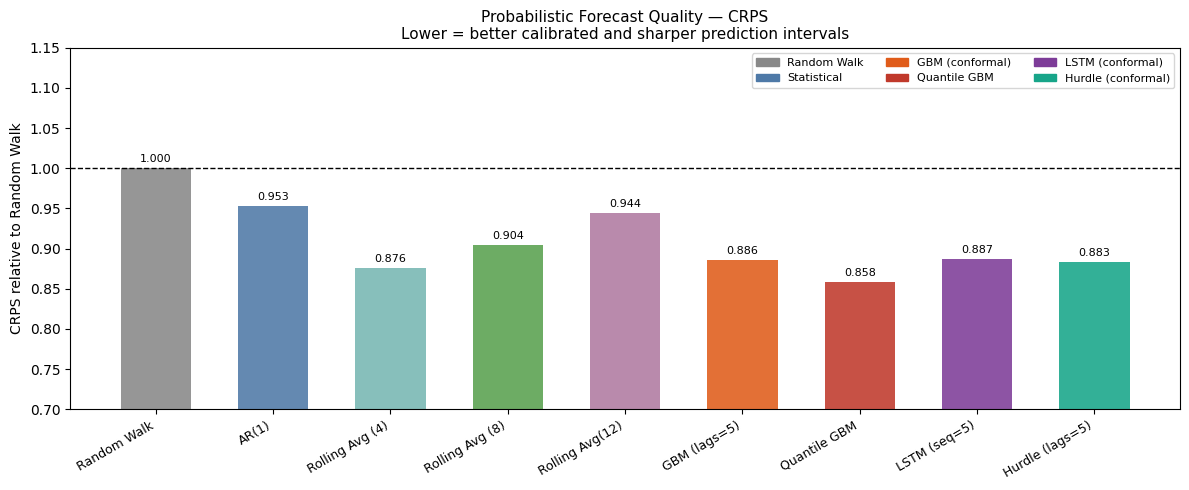

In [12]:
# ── Figure 1: CRPS bar chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))

models    = prob_table['Model'].tolist()
rel_crps  = prob_table['Rel. CRPS'].tolist()
colors    = [MODEL_COLORS.get(m, '#aaa') for m in models]

bars = ax.bar(range(len(models)), rel_crps, color=colors, width=0.6, alpha=0.88)
ax.axhline(1.0, color='black', linewidth=1.0, linestyle='--', label='Random Walk = 1.0')

for bar, val in zip(bars, rel_crps):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(range(len(models)))
ax.set_xticklabels(models, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('CRPS relative to Random Walk', fontsize=10)
ax.set_title('Probabilistic Forecast Quality — CRPS\n'
             'Lower = better calibrated and sharper prediction intervals', fontsize=11)
ax.set_ylim(0.7, 1.15)

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#888888', label='Random Walk'),
    Patch(color='#4e79a7', label='Statistical'),
    Patch(color='#e05c1a', label='GBM (conformal)'),
    Patch(color='#c0392b', label='Quantile GBM'),
    Patch(color='#7d3c98', label='LSTM (conformal)'),
    Patch(color='#17a589', label='Hurdle (conformal)'),
], fontsize=8, ncol=3)

plt.tight_layout()
plt.savefig(ROOT / 'results' / 'tables' / 'fig_crps_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Figure 2: Coverage vs Interval Width (calibration plot)

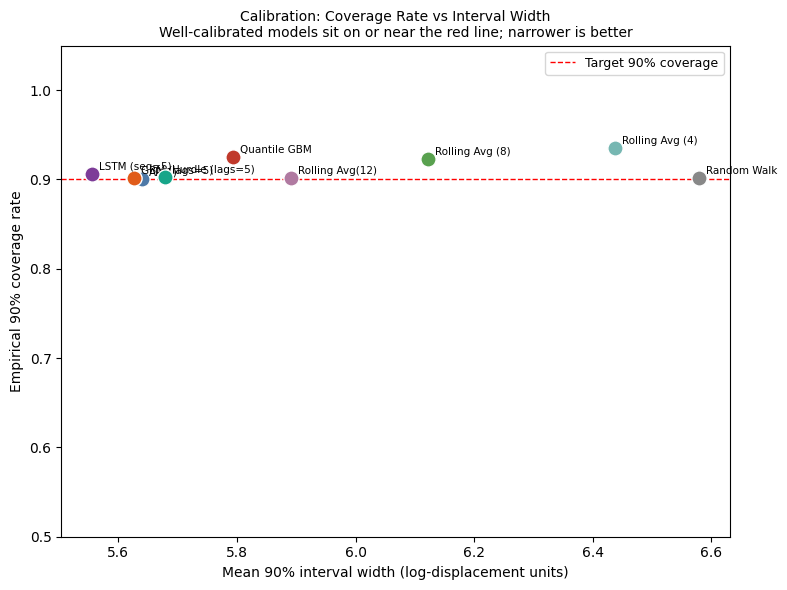

In [13]:
# ── Figure 2: Coverage vs Width scatter ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))

for _, row in prob_table.iterrows():
    color = MODEL_COLORS.get(row['Model'], '#aaa')
    ax.scatter(row['Interval Width'], row['Coverage 90%'],
               color=color, s=120, zorder=3, edgecolors='white', linewidths=1)
    ax.annotate(row['Model'], (row['Interval Width'], row['Coverage 90%']),
                xytext=(5, 3), textcoords='offset points', fontsize=7.5)

ax.axhline(0.90, color='red', linestyle='--', linewidth=1.0, label='Target 90% coverage')
ax.set_xlabel('Mean 90% interval width (log-displacement units)', fontsize=10)
ax.set_ylabel('Empirical 90% coverage rate', fontsize=10)
ax.set_title('Calibration: Coverage Rate vs Interval Width\n'
             'Well-calibrated models sit on or near the red line; narrower is better',
             fontsize=10)
ax.legend(fontsize=9)
ax.set_ylim(0.5, 1.05)
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'tables' / 'fig_coverage_width.png',
            dpi=150, bbox_inches='tight')
plt.show()

### Figure 3: Prediction intervals for a sample district

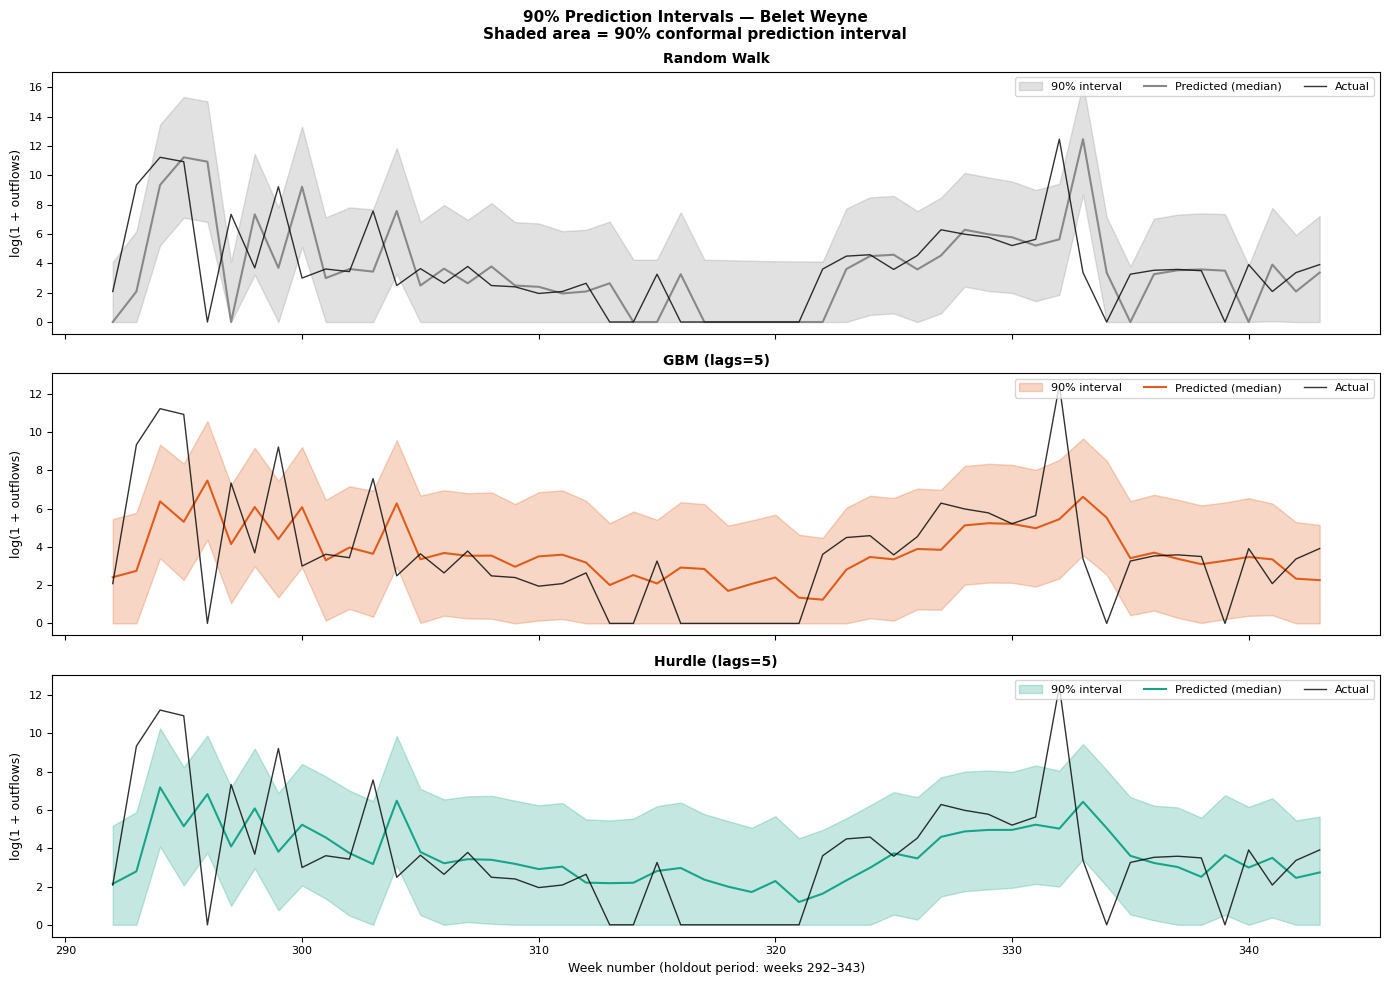

In [14]:
# ── Figure 3: Prediction intervals — Belet Weyne ──────────────────────────────
DISTRICT = 'Belet Weyne'

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
SHOW = ['Random Walk', 'GBM (lags=5)', 'Hurdle (lags=5)']

for ax, name in zip(axes, SHOW):
    df = prob_preds[name]
    d  = df[df['district'] == DISTRICT].sort_values('week_num')
    if len(d) == 0:
        ax.set_title(f'{name} — {DISTRICT} not found'); continue

    color = MODEL_COLORS.get(name, '#888')
    ax.fill_between(d['week_num'], d['q05'], d['q95'],
                    alpha=0.25, color=color, label='90% interval')
    ax.plot(d['week_num'], d['y_pred'],  color=color,   lw=1.5, label='Predicted (median)')
    ax.plot(d['week_num'], d['y_true'],  color='black', lw=1.0, alpha=0.8, label='Actual')
    ax.set_ylabel('log(1 + outflows)', fontsize=9)
    ax.set_title(f'{name}', fontsize=10, fontweight='bold')
    ax.legend(fontsize=8, loc='upper right', ncol=3)
    ax.tick_params(labelsize=8)

axes[-1].set_xlabel('Week number (holdout period: weeks 292–343)', fontsize=9)
fig.suptitle(f'90% Prediction Intervals — {DISTRICT}\n'
             'Shaded area = 90% conformal prediction interval',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'tables' / 'fig_prediction_intervals.png',
            dpi=150, bbox_inches='tight')
plt.show()

---
## Section 11 — Combined Table: Point + Probabilistic Metrics

In [15]:
# ── Load point prediction results from Notebook 01 ───────────────────────────
try:
    point_results = pd.read_csv(ROOT / 'results' / 'tables' / 'final_results.csv')
    print('Point results loaded from final_results.csv')
except:
    print('Run Notebook 01 first to generate final_results.csv')
    point_results = None

# ── Merge point + probabilistic ───────────────────────────────────────────────
combined = prob_table[['Model','CRPS','Rel. CRPS','Coverage 90%','Interval Width']].copy()

if point_results is not None:
    pt = point_results[['Model','RMSE','MAE','Corr']].copy()
    combined = combined.merge(pt, on='Model', how='left')

print('=== Combined Point + Probabilistic Results ===')
print(combined.to_string(index=False))
combined.to_csv(ROOT / 'results' / 'tables' / 'combined_results.csv', index=False)
print('\nSaved combined_results.csv')

Run Notebook 01 first to generate final_results.csv
=== Combined Point + Probabilistic Results ===
          Model   CRPS  Rel. CRPS  Coverage 90%  Interval Width
    Random Walk 1.1729      1.000         0.902          6.5799
          AR(1) 1.1180      0.953         0.900          5.6407
Rolling Avg (4) 1.0278      0.876         0.935          6.4382
Rolling Avg (8) 1.0603      0.904         0.923          6.1223
Rolling Avg(12) 1.1068      0.944         0.902          5.8913
   GBM (lags=5) 1.0394      0.886         0.902          5.6266
   Quantile GBM 1.0069      0.858         0.925          5.7929
   LSTM (seq=5) 1.0405      0.887         0.906          5.5552
Hurdle (lags=5) 1.0358      0.883         0.903          5.6791

Saved combined_results.csv
